In [1]:
import numpy as np
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import keras
import keras_nlp
import matplotlib.pyplot as plt
import seaborn as sns

2026-04-05 16:36:54.795263: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('punkt')

In [3]:
# load json files
human_listings = pd.read_json("scraping/agricultural/human_listings.json")
ai_listings = pd.read_json("scraping/agricultural/ai_listings.json")

# add source_model column to human listings
human_listings["source_model"] = "human"

# combine datasets
combined_listings = pd.concat([human_listings, ai_listings], ignore_index=True)

# encode target variable
# human = 0, ai = 1
combined_listings["target"] = combined_listings["label"].map({"Human": 0, "AI": 1})

# combine text features (name + description)
combined_listings["full_text"] = combined_listings["name"].fillna("") + " - " + combined_listings["description"].fillna("")

# drop unused columns
combined_listings_clean = combined_listings.drop(columns=["id", "url", "name", "description", "label"])

In [4]:
combined_listings_clean.head()

,source_model,target,full_text
0,human,0,Soulful Seeds - Soulful Seeds is a social and ...
1,human,0,"Urban Earth Care Farm - Urban Earth Care Farm,..."
2,human,0,Navarro Farm - The Navarro family 5-acre farm ...
3,human,0,The Farm At Our House - We are committed to su...
4,human,0,Arcadia Farm - Arcadia is a nonprofit organiza...


In [43]:
X_train_base, X_test_base, y_train, y_test = train_test_split(
    combined_listings_clean["full_text"],
    combined_listings_clean["target"],
    test_size=0.2,
    random_state=1,
    stratify=combined_listings_clean["target"]
)

In [44]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def deep_clean_text(text):
    # convert to lowercase
    text = text.lower()

    # remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # tokenize, remove stopwords, lemmatize
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    # rejoin into single string
    return " ".join(words)

In [45]:
# apply deep cleaning
X_train_svm = X_train_base.apply(deep_clean_text)
X_test_svm = X_test_base.apply(deep_clean_text)

# train TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

# fit only on training data, then transform both
X_train_tfidf = tfidf.fit_transform(X_train_svm)
X_test_tfidf = tfidf.transform(X_test_svm)

In [46]:
# initialize the SVM with linear kernel
svm_model = SVC(kernel='linear', random_state=1)

# train the model using the TF-IDF vectorized training data
svm_model.fit(X_train_tfidf, y_train)

# predict on the unseen test set
svm_preds = svm_model.predict(X_test_tfidf)

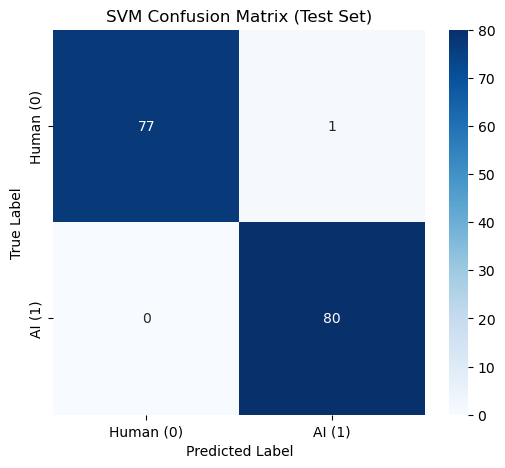


--- SVM Results ---
Accuracy: 0.9937

Classification Report:
              precision    recall  f1-score   support

   Human (0)       1.00      0.99      0.99        78
      AI (1)       0.99      1.00      0.99        80

    accuracy                           0.99       158
   macro avg       0.99      0.99      0.99       158
weighted avg       0.99      0.99      0.99       158



In [47]:
# predict on test set
svm_preds = svm_model.predict(X_test_tfidf)

# compute confusion matrix
conf_matrix = confusion_matrix(y_test, svm_preds)

# display confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Human (0)", "AI (1)"], 
            yticklabels=["Human (0)", "AI (1)"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SVM Confusion Matrix (Test Set)")
plt.show()

# evaluate SVM results
print("\n--- SVM Results ---")
print(f"Accuracy: {accuracy_score(y_test, svm_preds):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, svm_preds, target_names=['Human (0)', 'AI (1)']))

In [17]:
# Save trained SVM model and TF-IDF vectorizer for Streamlit app
import joblib
import os

os.makedirs('models', exist_ok=True)

# Save TF-IDF vectorizer and SVM model
joblib.dump(tfidf, 'models/tfidf_ag.pkl')
joblib.dump(svm_model, 'models/svm_ag.pkl')

print('Agricultural models saved to models/ directory')

Agricultural models saved to models/ directory


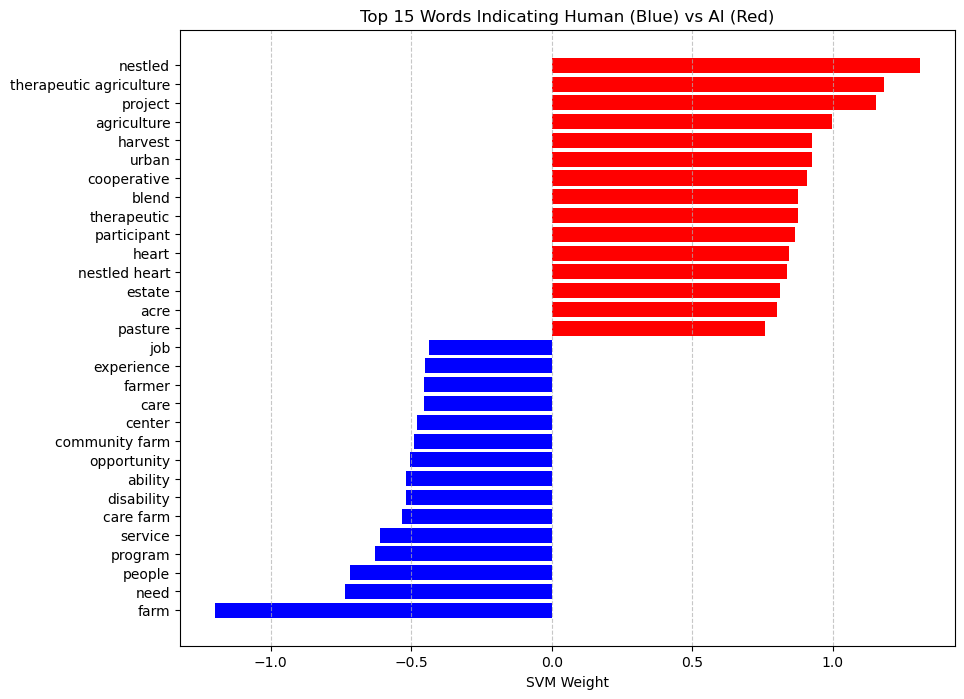

In [49]:
# Extract the coefficients and feature names
coefficients = svm_model.coef_.toarray()[0]
feature_names = tfidf.get_feature_names_out()

# Create a DataFrame of words and their weights
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Weight': coefficients
})

# Sort by weight
# Negative weights = Human (Class 0), Positive weights = AI (Class 1)
feature_importance = feature_importance.sort_values(by='Weight', ascending=True)

# Get top 15 words for Human and top 15 words for AI
top_human_words = feature_importance.head(15)
top_ai_words = feature_importance.tail(15)

# Combine them for the plot
top_features_combined = pd.concat([top_human_words, top_ai_words])

plt.figure(figsize=(10, 8))
# Color human words blue and AI words red
colors = ['blue' if x < 0 else 'red' for x in top_features_combined['Weight']]
plt.barh(top_features_combined['Feature'], top_features_combined['Weight'], color=colors)

plt.xlabel('SVM Weight')
plt.title('Top 15 Words Indicating Human (Blue) vs AI (Red)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [27]:
def light_clean_text(text):
    # remove HTML tags if present
    text = re.sub(r'<.*?>', '', text)

    # remove extra whitespaces/lines
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [20]:
# apply light cleaning
X_train_transformer = X_train_base.apply(light_clean_text).tolist()
X_test_transformer = X_test_base.apply(light_clean_text).tolist()

In [21]:
# split the dataset into training, validation, and test sets
X_train_transformer, X_temp, y_train, y_temp = train_test_split(
    X_train_transformer, y_train, test_size=0.25, random_state=1, stratify=y_train
    )
X_val_transformer, X_test_transformer, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=1, stratify=y_temp
    )

# initialize tokenizer and fit on training data
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_transformer)

# tokenize and pad sequences
def tokenize_and_pad(texts, tokenizer, max_length=100):
    sequences = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')
    return padded

X_train_padded = tokenize_and_pad(X_train_transformer, tokenizer)
X_val_padded = tokenize_and_pad(X_val_transformer, tokenizer)
X_test_padded = tokenize_and_pad(X_test_transformer, tokenizer)

In [22]:
embedding_dim = 128
max_length = 100

# define the model
model = Sequential([
    Input(shape=(max_length,)),
    Embedding(input_dim=10000, output_dim=embedding_dim),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# compile the model
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Ddsplay the model summary
model.summary()

Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼─────────────────────

In [23]:
# define callbacks
early_stopping = EarlyStopping(monitor="val_loss", patience=3, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1)

# train the model
history = model.fit(
    X_train_padded, y_train,
    validation_data=(X_val_padded, y_val),
    epochs=10,
    batch_size=32,
    verbose=1,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.5865 - loss: 0.6699 - val_accuracy: 0.8228 - val_loss: 0.5190 - learning_rate: 0.0010
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.9430 - loss: 0.2000 - val_accuracy: 0.9747 - val_loss: 0.1213 - learning_rate: 0.0010
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.9958 - loss: 0.0305 - val_accuracy: 1.0000 - val_loss: 0.0047 - learning_rate: 0.0010
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 1.0000 - loss: 0.0033 - val_accuracy: 1.0000 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 8.1504e-04 - learning_rate: 0.0010
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 1.0000 - loss: 8.7555e-04 - val_accuracy: 1.0000 - val_loss: 5.0803e-04 - learning_rate: 0.0010
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 1.0000 - loss: 5.85

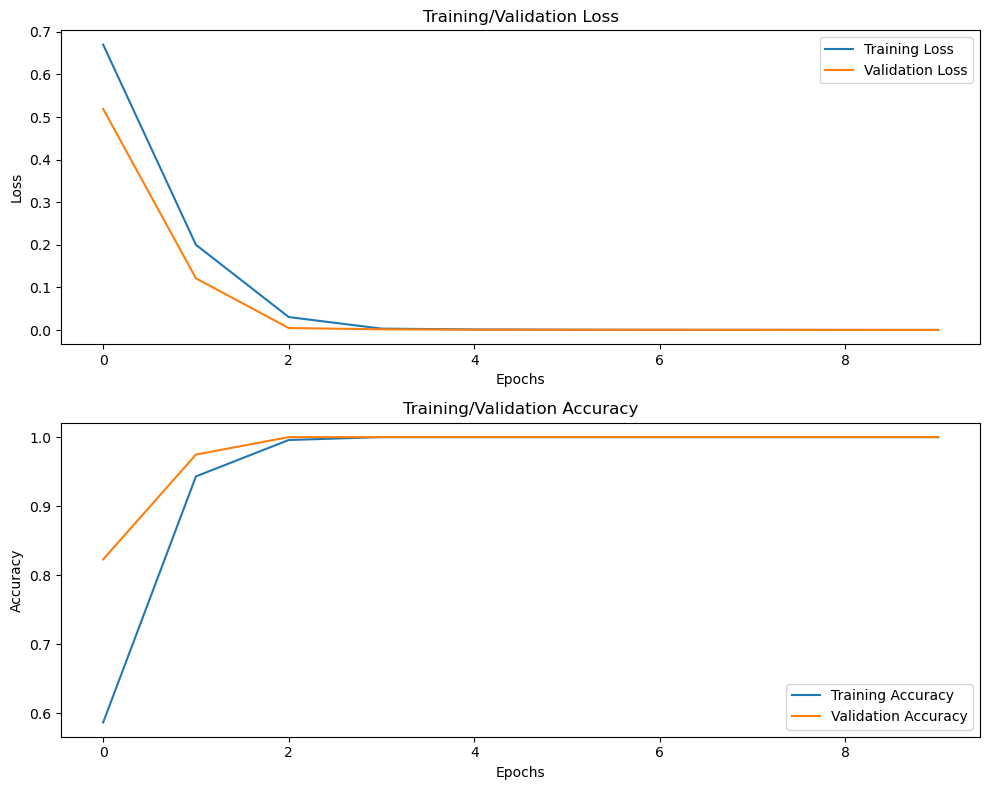

In [24]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.plot(history.history['loss'], linestyle='-', label='Training Loss')
plt.plot(history.history['val_loss'], linestyle='-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training/Validation Loss')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(history.history['accuracy'], linestyle='-', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], linestyle='-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training/Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 1.0000 - loss: 1.9807e-04
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


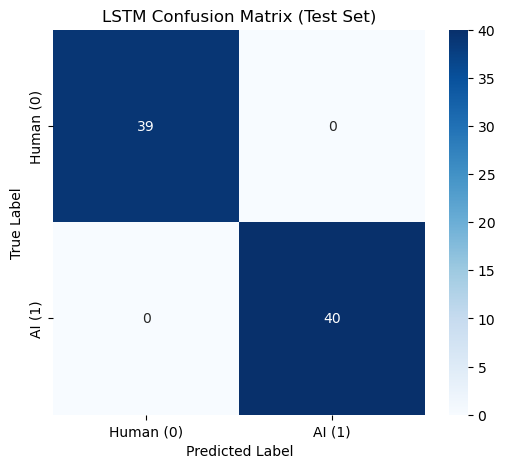


--- LSTM Results ---
Test Loss: 0.0002
Test Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

   Human (0)       1.00      1.00      1.00        39
      AI (1)       1.00      1.00      1.00        40

    accuracy                           1.00        79
   macro avg       1.00      1.00      1.00        79
weighted avg       1.00      1.00      1.00        79



In [25]:
# evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test_padded, y_test, verbose=1)

# get predictions (these will be probabilities due to the sigmoid activation)
test_preds = model.predict(X_test_padded)

# convert probabilities to binary labels (0 or 1) using a 0.5 threshold
pred_labels = (test_preds > 0.5).astype(int)

# compute confusion matrix
conf_matrix = confusion_matrix(y_test, pred_labels)

# display confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Human (0)", "AI (1)"], 
            yticklabels=["Human (0)", "AI (1)"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("LSTM Confusion Matrix (Test Set)")
plt.show()

# Print results
print("\n--- LSTM Results ---")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, pred_labels, target_names=["Human (0)", "AI (1)"]))

In [26]:
# convert labels to numpy arrays (to ensure compatibility)
y_train_np = np.array(y_train)
y_val_np = np.array(y_val)
y_test_np = np.array(y_test)

# define the pre-trained model
preset = "bert_tiny_en_uncased"

# create preprocessor
preprocessor = keras_nlp.models.BertPreprocessor.from_preset(
    preset=preset,
    sequence_length=128
)

# create classifier
classifier = keras_nlp.models.BertClassifier.from_preset(
    preset=preset,
    preprocessor=preprocessor,
    num_classes=2
)

# compile classifier
classifier.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),
    metrics=["accuracy"]
)

# display classifier summary
classifier.summary()

TypeError: <class 'keras_nlp.src.models.bert.bert_tokenizer.BertTokenizer'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras_nlp.src.models.bert.bert_tokenizer', 'class_name': 'BertTokenizer', 'config': {'name': 'bert_tokenizer', 'trainable': True, 'dtype': 'int32', 'vocabulary': None, 'sequence_length': None, 'lowercase': True, 'strip_accents': False, 'split': True, 'suffix_indicator': '##', 'oov_token': '[UNK]'}, 'registered_name': 'keras_nlp>BertTokenizer', 'assets': ['assets/tokenizer/vocabulary.txt'], 'weights': None}.

Exception encountered: Error when deserializing class 'BertTokenizer' using config={'name': 'bert_tokenizer', 'trainable': True, 'dtype': 'int32', 'vocabulary': None, 'sequence_length': None, 'lowercase': True, 'strip_accents': False, 'split': True, 'suffix_indicator': '##', 

In [ ]:
# define callbacks
early_stopping = EarlyStopping(monitor="val_loss", patience=3, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1)

# fine-tune the BERT model 
history = classifier.fit(
    x=X_train_transformer,
    y=y_train_np,
    validation_data=(X_val_transformer, y_val_np),
    epochs=10,
    batch_size=16,
    verbose=1,
    callbacks=[early_stopping, reduce_lr]
)

In [ ]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.plot(history.history['loss'], linestyle='-', label='Training Loss')
plt.plot(history.history['val_loss'], linestyle='-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training/Validation Loss')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(history.history['accuracy'], linestyle='-', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], linestyle='-', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training/Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# evaluate the fine-tuned BERT model
bert_test_loss, bert_test_accuracy = classifier.evaluate(
    x=X_test_transformer, 
    y=y_test_np, 
    verbose=1
)

# get predictions (these will be logits because from_logits=True)
test_preds = classifier.predict(X_test_transformer)

# convert logits to binary labels using argmax
pred_labels = np.argmax(test_preds, axis=1)

# compute confusion matrix
conf_matrix = confusion_matrix(y_test_np, pred_labels)

# display confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Human (0)", "AI (1)"], 
            yticklabels=["Human (0)", "AI (1)"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("BERT Confusion Matrix (Test Set)")
plt.show()

# Print results
print("\n--- BERT Results ---")
print(f"BERT Test Loss: {bert_test_loss:.4f}")
print(f"BERT Test Accuracy: {bert_test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_np, pred_labels, target_names=["Human (0)", "AI (1)"]))